# Graph Analyze : clustering

```networkx``` documentation available [here](https://networkx.org/documentation/stable/reference/algorithms/index.html)

## 0 - Data Reading

## 1 - Graph Definition
### 
use of the ```networkx``` to generate a graph from the matrix of similarities

## 2 - Graph Visualization

Colorbar: it shows how edge weights map to colors. We compute the minimum and maximum edge weights in the plotted graph, then linearly normalize each weight to [0, 1]. That normalized value is passed into the chosen colormap (default: viridis). Hence:
- lowest-weight edges take the colormap’s start color; highest-weight edges take the end color
- intermediate weights interpolate in between
Additionally, edge thickness scales with the same normalized weight (1 + 3 × normalized_weight), so strong connections stand out both in color and in width. If there are no edges, the colorbar is omitted.

## 3 - Clustering

### Method 1 - Louvain
#### In&Out
**Goal**: Detect **communities** in a graph by **maximizing modularity**.

**Inputs**
- A graph $G=(V,E)$ (weighted or unweighted).
- Optional parameters (as in `networkx.louvain_communities`):
  - `weight` (edge attribute)
  - `resolution` $\gamma$ (default 1)
  - `threshold`, `max_level`
  - `seed`

**Output**: A **list of sets**, each set = one community.

**Modularity**
For a partition $\{c_i\}$:

$$
Q = \frac{1}{2m} \sum_{i,j}
\left( A_{ij} - \gamma \frac{k_i k_j}{2m} \right)
\delta(c_i, c_j),
$$

where  
- $A_{ij}$: edge weight,  
- $k_i$: degree of node $i$,  
- $m = \tfrac12\sum_{ij}A_{ij}$.

#### How Louvain Works
**Iterate two phases**:

1. **Local move:**  
   Each node is moved to the neighboring community that yields the largest **modularity gain**  
   $$
   \Delta Q = \frac{1}{2m}\big(k_{i,C} - \gamma \frac{k_i\,\Sigma^{(C)}_{\text{tot}}}{2m}\big).
   $$

2. **Aggregation:**  
   Communities become super-nodes; edge weights between communities are summed.  
   Run phase 1 again on this compressed graph.

Stop when modularity no longer increases.

#### Minimal Example
```python
from networkx.algorithms.community import louvain_communities
import networkx as nx

G = nx.karate_club_graph()
communities = louvain_communities(G, resolution=1, seed=42)
print(communities)

c:\Users\mlafi\anaconda3\envs\comptools\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)
c:\Users\mlafi\anaconda3\envs\comptools\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:50: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(labels_pred)
c:\Users\mlafi\anaconda3\envs\comptools\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)
c:\Users\mlafi\anaconda3\envs\comptools\Lib\site-packages\sklearn\metrics\cluster\_superv

Best resolution: 0.2, modularity=0.9870, communities=20387
Robustness (ARI mean ± std at best resolution): 1.000 ± 0.000

Resolution  | Modularity(mean±std) | Avg #Communities
0.2        | 0.9870 ± 0.0000    | 20387.00
0.5        | 0.9870 ± 0.0000    | 20387.00
0.8        | 0.9870 ± 0.0000    | 20387.00
1.0        | 0.9870 ± 0.0000    | 20387.00
1.2        | 0.9870 ± 0.0000    | 20387.00
1.5        | 0.9870 ± 0.0000    | 20387.00
10.0       | 0.9870 ± 0.0000    | 20387.00


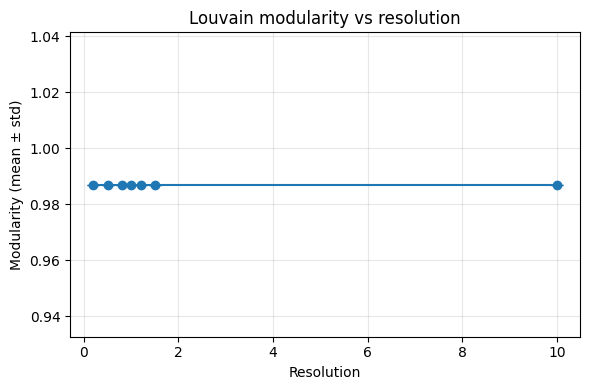

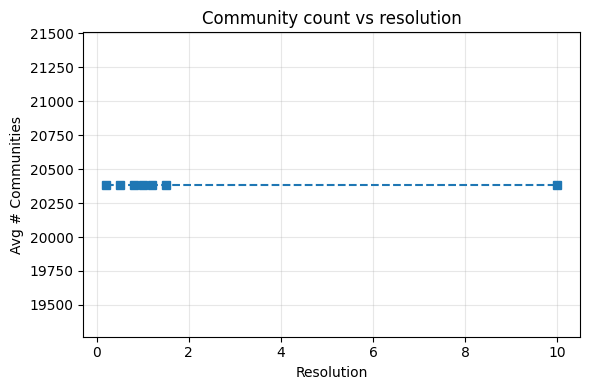

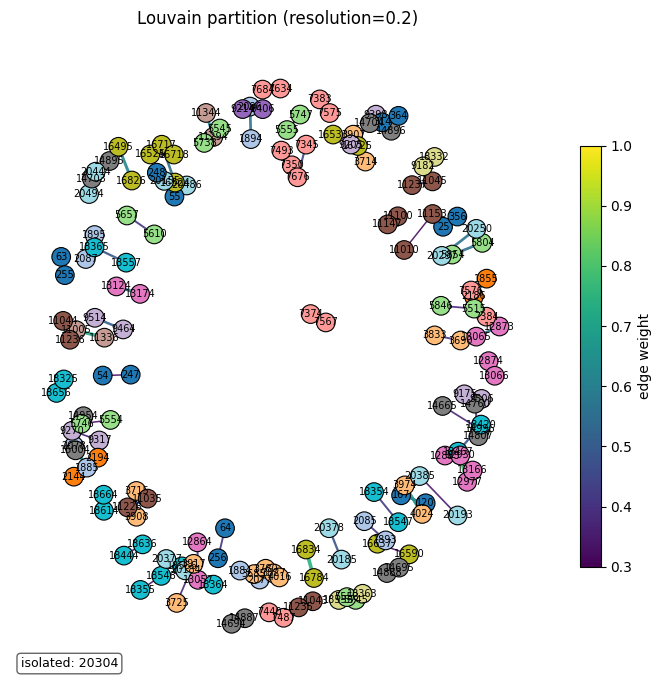


--- Export Louvain ---


### Method 2 - Girvan–Newman

The Girvan–Newman algorithm detects communities by iteratively removing the most “between” edges (bridges between groups).

Workflow

1. Compute edge betweenness centrality for every edge:
   
   $b_e = \sum_{s \ne t} \frac{\sigma_{st}(e)}{\sigma_{st}}$ where $\sigma_{st}$ is the number of shortest paths between $s$ and $t$, and $\sigma_{st}(e)$ is the number of those paths that go through edge $e$.
2. Remove the edge(s) with the highest betweenness.
3. Recompute betweenness on the new graph and repeat. This yields a hierarchy of partitions with an increasing number of communities.
4. Score each partition by modularity and select the best level:
   
   $$Q = \frac{1}{2m} \sum_{i,j} \Big(A_{ij} - \frac{k_i k_j}{2m}\Big) \, \delta(c_i, c_j)$$
   where $A_{ij}$ is the adjacency, $k_i$ is the degree of node $i$, $m$ is the total number of edges, and $\delta(c_i,c_j)=1$ if nodes $i$ and $j$ are in the same community.

Notes
- We evaluate partitions using NetworkX’s modularity and pick the maximum-$Q$ split (no need to predefine the number of clusters).
- Our visualization reuses the earlier function: nodes are colored by community, edges by weight with a colorbar.


### Greedy Modularity

Greedy modularity (Clauset–Newman–Moore) is a fast community detection heuristic that builds a partition by iteratively merging communities to maximize modularity.

Concepts

- Modularity Q: scores how well a partition captures dense intra-community connections and sparse inter-community connections. Higher Q indicates better community structure.
- Initial state: every node is its own community.
- Greedy merge: at each step, merge the pair of communities that yields the largest increase in Q (∆Q). Repeat until no merge improves Q.

Algorithm Sketch

1. Start with N singleton communities.
2. Precompute degrees and total edge weight m.
3. For each community pair (A,B), compute potential modularity gain ∆Q.
4. Pick the pair with maximum positive ∆Q and merge them.
5. Update gains for pairs touching the merged community.
6. Stop when no ∆Q > 0 remains; return the partition with maximum Q seen along the merges.

Properties

- Deterministic given node order and weights.
- Much faster than Girvan–Newman on large graphs.
- Produces a single partition (no hierarchy), optimized for modularity.

NetworkX Usage

- Function: `networkx.algorithms.community.greedy_modularity_communities(G, weight='weight')`
- Input: undirected graph `G` (use `G.to_undirected()` if needed).
- Output: tuple of sets, each set is a community.
- You can compute `Q` via `networkx.algorithms.community.modularity(G, communities, weight='weight')`.


AttributeError: module 'graph_clustering_lib' has no attribute 'run_greedy'

### 3 - Model Comparison

### Comparison Output Explained
This table summarizes how similar the two community partitions (Louvain vs Girvan–Newman) are. Higher values mean closer agreement.

- Rand: fraction of node pairs on which the methods agree (same cluster or different clusters). Range [0, 1].
- Adjusted Rand (ARI): Rand index corrected for chance; 0 ≈ random, 1 = identical; can be negative if worse than random.
- Jaccard (pair-counting): among pairs co-assigned by at least one method, the fraction co-assigned by both. Range [0, 1].
- NMI: normalized mutual information between labelings; invariant to label permutations. 0 = independent, 1 = identical.

Below the table, the printed line shows how many communities each method found (useful context when interpreting the scores).

c:\Users\mlafi\anaconda3\envs\comptools\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:50: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(labels_pred)
c:\Users\mlafi\anaconda3\envs\comptools\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:50: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(labels_pred)
c:\Users\mlafi\anaconda3\envs\comptools\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:50: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(labels_pred)


,Louvain vs GN
Rand,0.999927
Adjusted Rand (ARI),0.993903
Jaccard (pair-counting),0.987952
NMI,0.999056


Louvain communities: 83, GN communities: 84


**FINAL OUTPUT:** different clusters (subsets of predictions) with insights.
for each cluster, generate the following outputs:
- most common words
- most common signs
- most common topics
- a .csv file, subset of *horoscope_full.csv* with all predictions in the cluster.
- find the *'original prediction'*: the prediction that is the most similar to the other elements of the cluster, and (manually) check if the cluster makes sense